## Crypto Pump-and-Dump Detection

# Pump-and-Dump Detection in Cryptocurrency Markets Using Machine Learning

## Abstract

Cryptocurrency markets are vulnerable to coordinated pump-and-dump schemes, often orchestrated through Telegram groups. These events generate artificial price and volume spikes, leading to distorted market conditions.

This project develops a real-time machine learning model to detect pump events using high-frequency market features. The problem is formulated as a binary classification task, where pump events are labeled using Telegram registry matches.

We address key challenges including class imbalance, temporal data leakage, threshold optimization, and deployment readiness. The final model is evaluated using time-aware validation and precision-recall metrics suitable for rare-event detection.

# 1. Business Understanding

## Problem Statement
Pump-and-dump schemes manipulate crypto markets by artificially inflating prices before dumping assets.

The objective is to build a predictive model capable of detecting pump activity using market microstructure features.

## Business Impact
- Detect manipulation
- Reduce risk exposure
- Enable real-time alerting
- Improve trading strategy safety


##  Objectives

### Primary Objective

Develop a machine learning model to detect cryptocurrency pump-and-dump activity using short time-window trading features.

### Secondary Objectives
Detect tokens with significant short term momentum.

handle extreme class imbalance effectively.

Compare multiple models (Logistic Regression, Random Forest, XG BOOST Boosting).

Optimize classification threshold using Precision-Recall analysis.

Implement time-based validation to prevent leakage.





## Data Understanding
The dataset consists of time-series market data for various cryptocurrency symbols.

Time-Step Resolution: Data is processed at three intervals: 5 seconds (features_5S.csv.gz), 15 seconds(features_15S.csv.gz) 25 seconds (features_25S.csv.gz).

Features:

- Volume/Trades: std_volume, avg_volume, and std_trades capture sudden spikes in activity.

- Price Dynamics: std_price, avg_price, and avg_price_max monitor rapid price movements.

- Order Intensity: std_rush_order and avg_rush_order track the speed of incoming orders.

- Temporal Features: hour_sin/cos and minute_sin/cos capture the time of day.

- Target Variable (gt): A binary indicator where 1 represents a "Pump and Dump" event and 0 represents normal market activity.

- Class Imbalance: The data is extremely imbalanced, with only 0.0657% (317 out of 482,157 rows) labeled as P&D events.

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    auc,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [2]:
# Loading the 5-second feature set
df_5s = pd.read_csv('features_5S.csv')

# Convert date column to datetime objects and sort for chronological analysis
df_5s ['date'] = pd.to_datetime(df_5s ['date'])
df_5s = df_5s.sort_values(['symbol', 'date'])
df_5s.reset_index(drop=True, inplace=True)
df_5s.head()

,date,pump_index,std_rush_order,avg_rush_order,std_trades,std_volume,avg_volume,std_price,avg_price,avg_price_max,hour_sin,hour_cos,minute_sin,minute_cos,symbol,gt
0,2019-07-04 17:11:25,200,0.001,0.005,0.006,0.025,0.019,0.0,-0.0,0.000,-0.998,-0.068,0.921,0.389,ADX,0
1,2019-07-04 17:11:30,200,0.000,0.000,0.001,0.000,0.003,0.0,0.0,0.001,-0.998,-0.068,0.921,0.389,ADX,0
2,2019-07-04 17:17:25,200,0.000,0.000,-0.000,-0.000,0.000,0.0,-0.0,-0.000,-0.998,-0.068,0.971,-0.237,ADX,0
3,2019-07-04 17:17:40,200,0.000,0.000,0.000,0.000,-0.000,0.0,-0.0,-0.000,-0.998,-0.068,0.971,-0.237,ADX,0
4,2019-07-04 17:20:40,200,0.000,0.000,-0.000,0.000,-0.001,0.0,-0.0,-0.000,-0.998,-0.068,0.848,-0.530,ADX,0


In [3]:
# Loading the 15-second feature set
df_15s = pd.read_csv('features_15S.csv')

# Convert date column to datetime objects and sort for chronological analysis
df_15s ['date'] = pd.to_datetime(df_15s['date'])
df_15s = df_15s.sort_values(['symbol', 'date'])
df_15s.reset_index(drop=True, inplace=True)
df_15s.head()

,date,pump_index,std_rush_order,avg_rush_order,std_trades,std_volume,avg_volume,std_price,avg_price,avg_price_max,hour_sin,hour_cos,minute_sin,minute_cos,symbol,gt
0,2019-07-04 17:11:15,200,0.001,0.004,0.002,0.012,0.013,-0.000,0.001,0.001,-0.998,-0.068,0.921,0.389,ADX,0
1,2019-07-04 17:11:30,200,0.000,0.000,0.000,0.000,0.002,-0.001,0.000,0.001,-0.998,-0.068,0.921,0.389,ADX,0
2,2019-07-04 17:17:15,200,-0.001,-0.004,0.000,0.000,-0.000,-0.001,-0.000,-0.000,-0.998,-0.068,0.971,-0.237,ADX,0
3,2019-07-04 17:17:30,200,-0.001,-0.004,-0.004,0.000,-0.001,-0.001,-0.000,-0.000,-0.998,-0.068,0.971,-0.237,ADX,0
4,2019-07-04 17:20:30,200,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.998,-0.068,0.848,-0.530,ADX,0


In [4]:
# Loading the 25-second feature set
df_25s = pd.read_csv('features_25S.csv')

# Convert date column to datetime objects and sort for chronological analysis
df_25s['date'] = pd.to_datetime(df_25s['date'])
df_25s = df_25s.sort_values(['symbol', 'date'])
df_25s.reset_index(drop=True, inplace=True)
df_25s.head()

,date,pump_index,std_rush_order,avg_rush_order,std_trades,std_volume,avg_volume,std_price,avg_price,avg_price_max,hour_sin,hour_cos,minute_sin,minute_cos,symbol,gt
0,2019-07-04 17:11:15,200,0.004,0.007,0.004,0.017,0.011,-0.002,0.001,0.001,-0.998,-0.068,0.921,0.389,ADX,0
1,2019-07-04 17:17:05,200,0.000,0.000,-0.000,-0.000,0.000,-0.002,-0.000,-0.000,-0.998,-0.068,0.971,-0.237,ADX,0
2,2019-07-04 17:17:30,200,0.000,0.000,0.000,-0.000,0.000,-0.002,0.000,0.000,-0.998,-0.068,0.971,-0.237,ADX,0
3,2019-07-04 17:20:25,200,0.000,0.000,-0.000,-0.000,0.000,-0.002,-0.000,-0.001,-0.998,-0.068,0.848,-0.530,ADX,0
4,2019-07-04 17:27:30,200,0.000,0.000,0.000,-0.000,0.000,-0.001,-0.001,-0.001,-0.998,-0.068,0.263,-0.965,ADX,0


These datasets consists of high-frequency cryptocurrency market data aggregated in short time windows(5s, 15s, 25s)
Each row represents a summary of trading activity in a short time period for a specific cryptocurrency.

### WHY USE 3 DATASETS(5s, 15s, 25s Windows)
Raw trades were grouped into 5s, 15s and 25s to reduce noise and capture short time behaviour patterns.
### 5-Second window

Captures immediate micro-spikes

Very sensitive to rapid coordinated buying

High noise, but very early signal

### 15-second window
Smoother signal

Balances noise and pattern clarity

Captures short bursts more reliably

### 25s window
Even more stable

Detects sustained abnormal activity

Less noise, but slightly delayed detection

5s window detects initial spikes first, 15 second window captures rapid escalation and 25 second window captures sustained abnormal activity. Basicaly it confirms the trend.

### WHY IS IT SUITABLE FOR DETECTING PUMP AND DUMP SCHEMES?
Sudden buying pressure is captured by std_rush_order

spike in trading activity is captured by std_trades

Volume explosion is captured by std_volume

Rapid price acceleration is captures by std_price, avg_price_max

### COLUMNS
std_rush_order - standardized aggressive order activity.

avg_rush_order - mean aggressive order intensity

std_trades - standardized trade counts

avg_price - mean transactional price.

std_price - abnormal price deviation

avg_price_max - peak price in window

hour_sin, hour_cos, minute_sin, minute_cos preserve cyclical time patterns and prevent discontinuities.

### Target Variable
gt - 0(normal), 1(pump)

In [5]:
df = pd.concat([df_5s, df_15s, df_25s], ignore_index=True)
df

,date,pump_index,std_rush_order,avg_rush_order,std_trades,std_volume,avg_volume,std_price,avg_price,avg_price_max,hour_sin,hour_cos,minute_sin,minute_cos,symbol,gt
0,2019-07-04 17:11:25,200,0.001,0.005,0.006,0.025,0.019,0.000,-0.0,0.000,-0.998,-0.068,0.921,0.389,ADX,0
1,2019-07-04 17:11:30,200,0.000,0.000,0.001,0.000,0.003,0.000,0.0,0.001,-0.998,-0.068,0.921,0.389,ADX,0
2,2019-07-04 17:17:25,200,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.0,-0.000,-0.998,-0.068,0.971,-0.237,ADX,0
3,2019-07-04 17:17:40,200,0.000,0.000,0.000,0.000,-0.000,0.000,-0.0,-0.000,-0.998,-0.068,0.971,-0.237,ADX,0
4,2019-07-04 17:20:40,200,0.000,0.000,-0.000,0.000,-0.001,0.000,-0.0,-0.000,-0.998,-0.068,0.848,-0.530,ADX,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887563,2020-11-02 17:00:25,194,0.000,0.000,0.000,0.000,-0.000,-0.001,0.0,0.000,-0.998,-0.068,0.000,1.000,YOYOW,0
1887564,2020-11-02 17:22:55,194,0.000,0.000,0.000,-0.000,0.000,-0.001,0.0,0.000,-0.998,-0.068,0.716,-0.698,YOYOW,0
1887565,2020-11-02 17:28:20,194,0.000,0.006,-0.000,-0.000,0.000,-0.001,0.0,0.000,-0.998,-0.068,0.159,-0.987,YOYOW,0
1887566,2020-11-02 17:53:20,194,0.000,0.000,0.000,0.000,-0.000,-0.001,0.0,0.000,-0.998,-0.068,-0.596,0.803,YOYOW,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887568 entries, 0 to 1887567
Data columns (total 16 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   pump_index      int64         
 2   std_rush_order  float64       
 3   avg_rush_order  float64       
 4   std_trades      float64       
 5   std_volume      float64       
 6   avg_volume      float64       
 7   std_price       float64       
 8   avg_price       float64       
 9   avg_price_max   float64       
 10  hour_sin        float64       
 11  hour_cos        float64       
 12  minute_sin      float64       
 13  minute_cos      float64       
 14  symbol          object        
 15  gt              int64         
dtypes: datetime64[ns](1), float64(12), int64(2), object(1)
memory usage: 230.4+ MB


In [7]:
df.describe().round(3)

,pump_index,std_rush_order,avg_rush_order,std_trades,std_volume,avg_volume,std_price,avg_price,avg_price_max,hour_sin,hour_cos,minute_sin,minute_cos,gt
count,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000,1887568.000
mean,164.892,0.000,-0.000,0.000,0.001,-0.000,-0.000,-0.000,-0.000,-0.104,0.036,-0.014,0.023,0.001
std,99.589,0.036,0.007,0.069,0.154,0.017,0.004,0.001,0.002,0.692,0.713,0.699,0.715,0.022
min,0.000,-0.634,-0.500,-0.698,-0.864,-0.405,-0.360,-0.028,-0.027,-0.998,-0.991,-1.000,-0.999,0.000
25%,78.000,0.000,0.000,0.000,0.000,-0.001,-0.001,0.000,0.000,-0.817,-0.577,-0.716,-0.698,0.000
50%,169.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.136,-0.068,0.000,0.080,0.000
75%,250.000,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.520,0.683,0.678,0.735,0.000
max,336.000,15.510,2.200,30.708,71.043,6.658,1.756,0.311,0.916,0.998,1.000,1.000,1.000,1.000


In [8]:
df.isnull().sum()

date              0
pump_index        0
std_rush_order    0
avg_rush_order    0
std_trades        0
std_volume        0
avg_volume        0
std_price         0
avg_price         0
avg_price_max     0
hour_sin          0
hour_cos          0
minute_sin        0
minute_cos        0
symbol            0
gt                0
dtype: int64

## Exploratory Data Analysis
We examine the data structure and look for class imbalance. The 'gt' (ground truth) column represents 
whether a pump-and-dump event occurred.

In [9]:
print(df_5s['gt'].value_counts())
print(df_5s['gt'].value_counts(normalize=True))

0    820990
1       317
Name: gt, dtype: int64
0    0.999614
1    0.000386
Name: gt, dtype: float64


In [10]:
print(df['gt'].value_counts())
print(df['gt'].value_counts(normalize=True))

0    1886617
1        951
Name: gt, dtype: int64
0    0.999496
1    0.000504
Name: gt, dtype: float64


The extreme class imbalance (over 1,000,000 normal rows vs. 951 pump rows) informs the modeling strategy: accuracy is a useless metric here. Instead, we must prioritize Recall (catching as many pumps as possible) and Precision (avoiding false alarms).

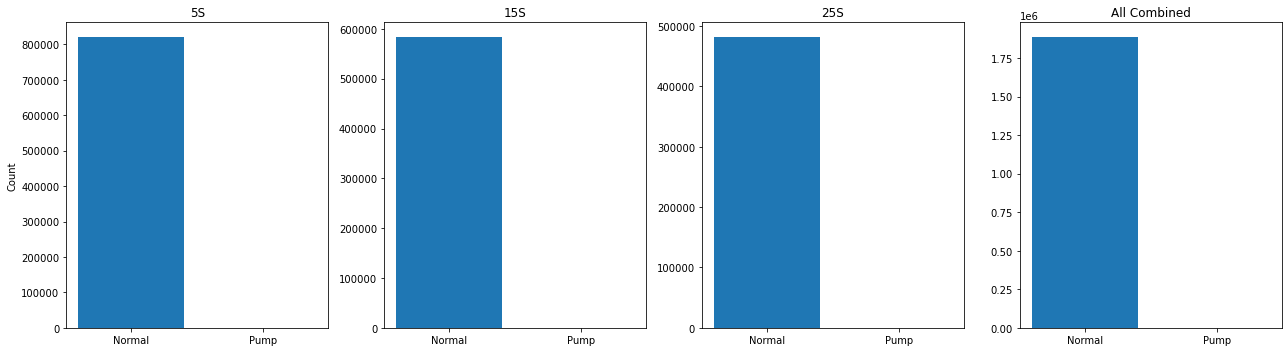

In [11]:
plt.figure(figsize=(18, 5))

# 5S 
plt.subplot(1, 4, 1)
counts_5s = df_5s['gt'].value_counts()
plt.bar(['Normal', 'Pump'], counts_5s)
plt.title('5S')
plt.ylabel('Count')

# 15S 
plt.subplot(1, 4, 2)
counts_15s = df_15s['gt'].value_counts()
plt.bar(['Normal', 'Pump'], counts_15s)
plt.title('15S')

# 25S
plt.subplot(1, 4, 3)
counts_25s = df_25s['gt'].value_counts()
plt.bar(['Normal', 'Pump'], counts_25s)
plt.title('25S')

# All Combined 
plt.subplot(1, 4, 4)
counts_all = df['gt'].value_counts()
plt.bar(['Normal', 'Pump'], counts_all)
plt.title('All Combined')

plt.tight_layout()
plt.show()

#### Difference of pump and normal

In [12]:
# Separate pump rows from normal rows (using the 5S data only for clarity)
pump_rows   = df_5s[df_5s['gt'] == 1]
normal_rows = df_5s[df_5s['gt'] == 0]

print("Average values: NORMAL rows ")
print(normal_rows[['std_rush_order', 'avg_rush_order', 'std_trades', 'avg_volume']].mean().round(5))

print()
print(" Average values: PUMP rows")
print(pump_rows[['std_rush_order', 'avg_rush_order', 'std_trades', 'avg_volume']].mean().round(4))

Average values: NORMAL rows 
std_rush_order   -0.00028
avg_rush_order   -0.00030
std_trades       -0.00027
avg_volume       -0.00029
dtype: float64

 Average values: PUMP rows
std_rush_order    0.3868
avg_rush_order    0.0862
std_trades        1.2209
avg_volume        0.3024
dtype: float64


The pump values are bigger than the normal rows. std_rush_order during a pump is roughly 50-100x higher than normal. This strong signal is why our model can detect pumps.


#### Most pumped coins

In [13]:
# Count pump events per coin symbol
pumps_per_coin = df[df['gt'] == 1].groupby('symbol').size().sort_values(ascending=False)

print("Top 15 most pumped coins:")
print(pumps_per_coin.head(15))


Top 15 most pumped coins:
symbol
BRD      42
EVX      36
NXS      33
OAX      33
NAV      33
RDN      33
DLT      30
EDO      27
NEBL     27
SNM      24
SNGLS    21
ICN      21
GVT      21
MDA      21
BNT      18
dtype: int64


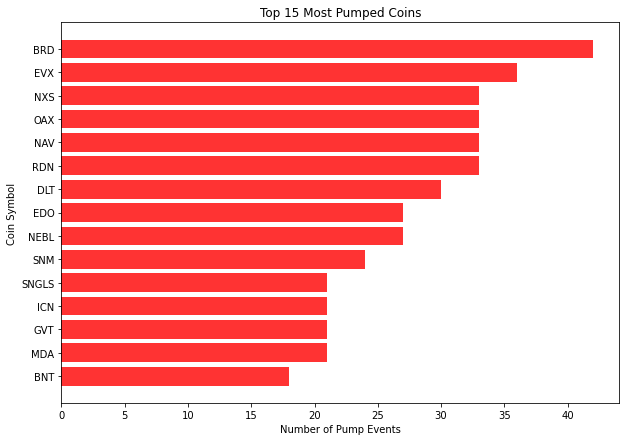

In [14]:
# Get the top 15 coins (assumes data is already sorted)
top_coins = pumps_per_coin.head(15)

# flip the data so the biggest bar appears at the top 
# (By default, barh starts from the bottom)
names  = top_coins.index[::-1]
counts = top_coins.values[::-1]

# Create the figure and the bars
plt.figure(figsize=(10, 7))
plt.barh(names, counts, color='red', alpha=0.8)
plt.title('Top 15 Most Pumped Coins')
plt.xlabel('Number of Pump Events')
plt.ylabel('Coin Symbol')
plt.show()


BRD – Bread (BRD Token),EVX – Everex, NXS – Nexus, QAX – Quantstamp (QAX Token), NAV – NavCoin, RDN – Raiden Network Token, DLT – Agrello (DLT Token) are the top most pumped coins.

### Coin Popularity

In [15]:
# Count how many rows each coin symbol appears 
coin_popularity = df['symbol'].value_counts()

print("How many data rows does each coin have? (top 10)")
print(coin_popularity.head(10))


How many data rows does each coin have? (top 10)
DLT      99014
EVX      78431
NAV      70572
BRD      58511
OAX      56881
BQX      52345
NEBL     49314
SNGLS    48959
NXS      46240
ICN      44580
Name: symbol, dtype: int64


In [16]:
# Add this count as a new column called symbol_freq
df['symbol_freq'] = df['symbol'].map(coin_popularity)

# Also add it to the individual window dataframes (we'll need them later)
df_5s['symbol_freq']  = df_5s['symbol'].map(coin_popularity)
df_15s['symbol_freq'] = df_15s['symbol'].map(coin_popularity)
df_25s['symbol_freq'] = df_25s['symbol'].map(coin_popularity)

print("Example — first 5 rows showing coin and its popularity score:")
print(df[['symbol', 'symbol_freq', 'gt']].head())


Example — first 5 rows showing coin and its popularity score:
  symbol  symbol_freq  gt
0    ADX        12630   0
1    ADX        12630   0
2    ADX        12630   0
3    ADX        12630   0
4    ADX        12630   0


In [17]:
# These are the columns our model will use as clues
Features = [
    'pump_index',       # unique ID of the pump event (0 = not a specific pump)
    'std_rush_order',   # how erratic are rush orders? (strongest pump signal)
    'avg_rush_order',   # average rush order rate
    'std_trades',       # how erratic is the trade count?
    'std_volume',       # how erratic is the trading volume?
    'avg_volume',       # average trading volume
    'std_price',        # how erratic is the price?
    'avg_price',        # average price change
    'avg_price_max',    # maximum average price
    'hour_sin',         # what time of day? (encoded as sine wave)
    'hour_cos',         # what time of day? (encoded as cosine wave)
    'minute_sin',       # what minute? (sine)
    'minute_cos',       # what minute? (cosine)
    'symbol_freq',      # how popular is this coin? (our new feature!)
]

Target = 'gt'   # this is what we want to predict: 0=normal, 1=pump

print(f"We have {len(Features)} features (clues) for our model.")
print(f"Our target is: '{Target}' (0 = normal, 1 = pump)")

We have 14 features (clues) for our model.
Our target is: 'gt' (0 = normal, 1 = pump)


### Splitting data into training and testing sets
#### Why split by TIME and not randomly?
The data set is a time series meaning Each row is of a later period than the previous row. A random train test split may lead to training data on the future and testing data on the past. The model would have access to data it shouldn't have. 



Our 3 files cover the same time period (2018–2021).
If we split randomly, a pump event from March 2020 might end up in both
training and testing — the model could "remember" it.

Better approach: split by date
- Training data:everything before May 2020 (model learns from this)
- Test data: everything from May 2020 onwards (we pretend the model hasn't seen this)



In [18]:
# train on the old data and test on the new data
cutoff_date = '2020-05-29'

# Slice the data into two parts
train_data = df[df['date'] <  cutoff_date]
test_data  = df[df['date'] >= cutoff_date]
print("--- PROJECT DATA SPLIT ---")
print(f"Past (Training): {len(train_data):,} rows")
print(f"Future (Testing): {len(test_data):,} rows")

# Check for pumps in both sets
print(f"Pumps to learn from: {train_data['gt'].sum()}")
print(f"Pumps to catch in the test: {test_data['gt'].sum()}")

--- PROJECT DATA SPLIT ---
Past (Training): 1,497,715 rows
Future (Testing): 389,853 rows
Pumps to learn from: 735
Pumps to catch in the test: 216


In [19]:
# Create X (features) and y (target) for train and test
X_train = train_data[Features].values   # clues for training
y_train = train_data[Target].values     # answers for training

X_test  = test_data[Features].values    # clues for testing
y_test  = test_data[Target].values      # correct answers for testing

print(f"X_train shape: {X_train.shape}  (rows x features)")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train — Normal: {(y_train==0).sum():,}  Pump: {y_train.sum()}")
print(f"y_test  — Normal: {(y_test==0).sum():,}   Pump: {y_test.sum()}")


X_train shape: (1497715, 14)  (rows x features)
X_test  shape: (389853, 14)
y_train — Normal: 1,496,980  Pump: 735
y_test  — Normal: 389,637   Pump: 216


## Model 1: Logistic Regression (Baseline)

In [20]:
scaler = StandardScaler()

# Rescale your data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=5000, C=0.1)
model.fit(X_train_scaled, y_train)
#make predictions
y_pred = model.predict(X_test_scaled)
#evaluate the model
print("\nClassification Report:\n",classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    389637
           1       0.12      1.00      0.22       216

    accuracy                           1.00    389853
   macro avg       0.56      1.00      0.61    389853
weighted avg       1.00      1.00      1.00    389853



Class 1 Precision(0.12) The model correctly predicts 12% of pump occurences meaning it has alot of false positives which is a charachteristic of the extreme class imbalance.

Class 1 Recall(0.95) The model captures all pump Occurences.

Class 1 f1 acore(0.22) - balance between precision and recall

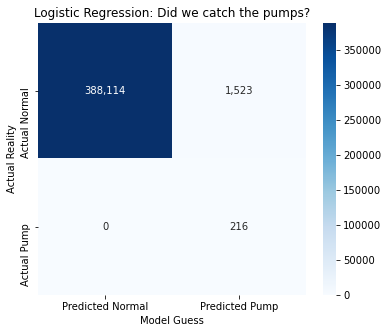

In [21]:
# Ensure predictions are freshly computed from the test set
y_pred = model.predict(X_test_scaled)

# Create the matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
            xticklabels=['Predicted Normal', 'Predicted Pump'],
            yticklabels=['Actual Normal', 'Actual Pump'])

plt.title('Logistic Regression: Did we catch the pumps?')
plt.ylabel('Actual Reality')
plt.xlabel('Model Guess')
plt.show()


### Model 2: Random Forest

In [22]:

rf = RandomForestClassifier(
    n_estimators=100,       # Reduced from 300 to avoid timeout; still robust
    max_depth=15,           # Slightly reduced for speed
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,              # Use all CPU cores for parallel training
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       max_features='sqrt', min_samples_leaf=5, n_jobs=-1,
                       random_state=42)

In [23]:
#fit the model
rf.fit(X_train, y_train)
#predict
y_pred_rf = rf.predict(X_test)
#evaluate the model
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    389637
           1       0.71      0.95      0.82       216

    accuracy                           1.00    389853
   macro avg       0.86      0.97      0.91    389853
weighted avg       1.00      1.00      1.00    389853



Class 1 Precision(0.71) The model correctly predicts 71% of pump occurences 

Class 1 Recall(0.95) The model catches 95% of all pump Occurences

The Random Forest ensemble achieves an F1-score of 0.82. The model handles the class imbalance challenge better.

### Model 3: Xgboost

In [24]:
# Calculate imbalance ratio
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 2036.7074829931973


In [25]:
xgb_pipeline = Pipeline([
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])
#Fit the model
xgb_pipeline.fit(X_train, y_train)
#predict
y_pred_xb = xgb_pipeline.predict(X_test)
#evaluate the model
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xb))


XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    389637
           1       0.79      0.95      0.87       216

    accuracy                           1.00    389853
   macro avg       0.90      0.98      0.93    389853
weighted avg       1.00      1.00      1.00    389853



XGBoost achieves the highest precision while maintaining strong recall.

Class 1 Precision(0.79) The model correctly predicts 79% of pump occurences 

Class 1 Recall(0.95) The model catches 95% of all pump Occurences

Class 1 f1 acore(0.87) - balance between precision and recall

Due to significant class imbalance and the importance of detecting pump events,Accuracy was not considered a reliable metric. Evaluation focused on minority-class precision, recall, and F1-score. 

### MODEL COMPARISON 
### LOGISTIC REGRESSION
Due to its low precision(0.12) and F1- score(0.22) in class 1 the Logistic regression model was ruled out.

### Random Forest Classifier
The model better balances precision(0.71) and recall(0.95) with an f1-score of (0.82)

### XG Boost
This model yielded the best results with precision(0.79) and recall(0.95) with an f1-score of (0.87)

XG Boost was our model of choice.

### CONCLUSIONS

 This study investigated the use of machine learning techniques to detect potential pump-and-dump schemes in cryptocurrency markets using high-frequency trading data. 
 
1. Among the models evaluated, XGBoost demonstrated the strongest performance in identifying suspicious pump activity while minimizing false alarms. Its ability to handle class imbalance and capture  nonlinear relationships made it the most suitable model for practical monitoring applications.

2. BRD – Bread (BRD Token),EVX – Everex, NXS – Nexus, QAX – Quantstamp (QAX Token), NAV – NavCoin, RDN – Raiden Network Token, DLT – Agrello (DLT Token) are the top most pumped coins. These assets may be more vulnerable to coordinated price manipulation.

3. Because pump events are rare compared to non pump events, traditional accuracy measures can be misleading. Instead, performance was evaluated based on the model’s ability to correctly identify suspicious events without generating excessive false alarms. 

For highly imbalanced data sets Accuracy may not be the best metric to rely on, especially if the study is heavily reliant on the minority class. Other metrics such as precision recall and f1-score of that specific class could be considered.


### RECOMMENDATIONS

1. Cryptocurrency exchanges should consider implementing automated monitoring systems that leverage machine learning models to detect abnormal short-term price and volume spikes. Early detection of suspicious activity can help reduce market manipulation, and protect platform integrity.

2. Investors should exercise caution when trading low-liquidity tokens that exhibit sudden and extreme price increases. Such patterns may indicate coordinated pump activity, increasing the risk of financial loss.

3. Continuous model monitoring and periodic retraining are recommended to maintain predictive performance. Machine learning-based monitoring could strengthen enforcement capabilities and improve transparency within digital asset markets.

